max |U†U - I| = 1.4432899320127035e-14
done; max |z| = 0.009531922486049773


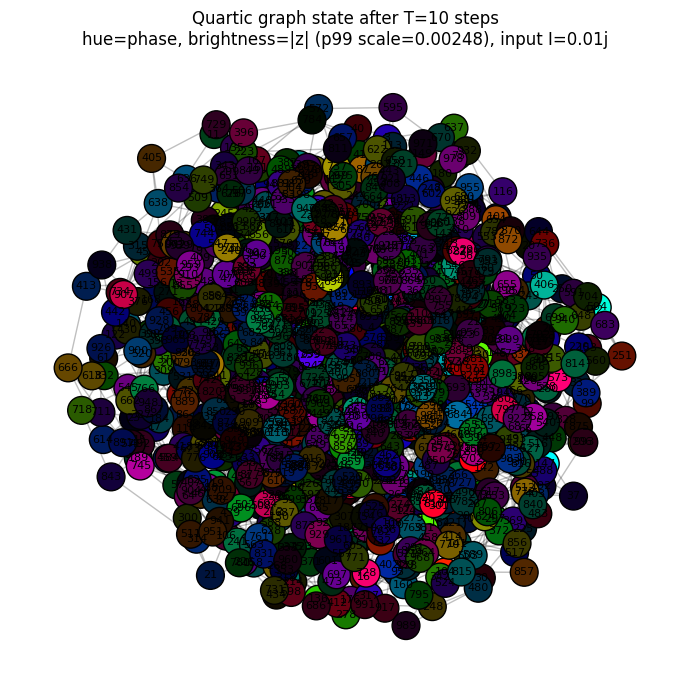

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm
from matplotlib.colors import hsv_to_rgb
np.random.seed(0)

n = 1000
d = 4
T = 10
I = 0.0 + 0.01j          # constant complex input added to node 0 each step
dt = 1.0                  # optional scale for the generator i*L

def phi(Z):
    return Z / np.sqrt(1.0 + np.abs(Z)**2)

# Random quartic (4-regular) graph named Z
Z = nx.random_regular_graph(d=d, n=n, seed=0)  # nodes are 0..n-1 by default

# Graph Laplacian L (Hermitian/symmetric) and anti-Hermitian generator A = i*L
A_adj = nx.to_numpy_array(Z, nodelist=range(n), dtype=float)
deg = A_adj.sum(axis=1)
L = np.diag(deg) - A_adj                 # combinatorial Laplacian, symmetric real
A = 1j * dt * L                          # anti-Hermitian (since L^T=L => (iL)† = -iL)
# Unitary kernel
U = expm(A)                              # should be unitary (up to numerical error)

# Quick sanity check: U†U ≈ I
unitarity_err = np.max(np.abs(U.conj().T @ U - np.eye(n)))
print("max |U†U - I| =", unitarity_err)

# Recurrent update: z <- phi(U z + I_vec)
z = np.zeros(n, dtype=np.complex128)     # node states
I_vec = np.zeros(n, dtype=np.complex128)
I_vec[0] = I

for t in range(T):
    z_lin = U @ z + I_vec
    z = phi(z_lin)

print("done; max |z| =", np.max(np.abs(z)))

# Visualization: phase as hue, magnitude as brightness
mag = np.abs(z)
scale = np.percentile(mag, 99) if np.any(mag) else 1.0
scale = float(scale) if scale > 0 else 1.0
v = np.clip(mag / scale, 0.0, 1.0)                 # value/brightness
h = (np.angle(z) + np.pi) / (2 * np.pi)            # hue in [0,1]
s = np.ones_like(h)                                 # full saturation
rgb = hsv_to_rgb(np.stack([h, s, v], axis=-1))
pos = nx.spring_layout(Z, seed=0)  # layout for visualization (not part of dynamics)

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(Z, pos, alpha=0.25, width=1.0)
nx.draw_networkx_nodes(
    Z, pos,
    node_color=rgb,
    node_size=400,
    linewidths=1.0,
    edgecolors="black"
)
nx.draw_networkx_labels(Z, pos, font_size=8)

plt.title(f"Quartic graph state after T={T} steps\n"
          f"hue=phase, brightness=|z| (p99 scale={scale:.3g}), input I={I}")
plt.axis("off")
plt.tight_layout()
plt.show()

Ollivier-Ricci curvature on 2000 edges:
  mean  = -0.9712
  std   = 0.1120
  min   = -1.0000
  max   = -0.2500


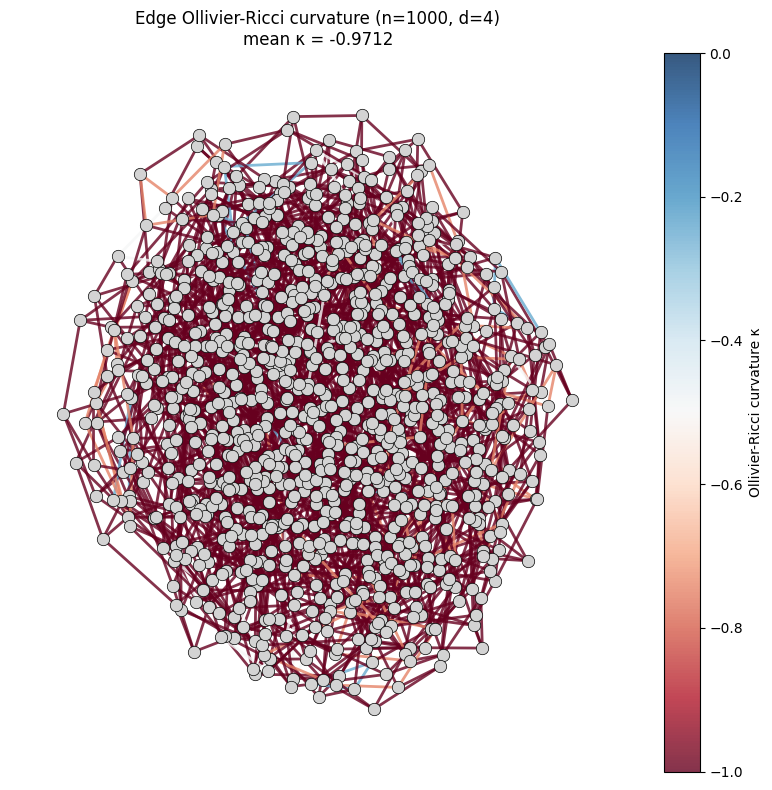

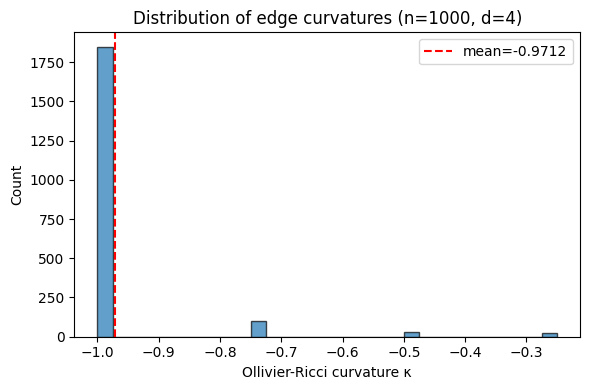

In [39]:
# Cell: #VSC-27ef2dcb
import numpy as np
import networkx as nx
from scipy.optimize import linprog
d=4
Z = nx.random_regular_graph(d=d, n=1000, seed=0)  # nodes are 0..n-1 by default

# --- Ollivier-Ricci curvature ---
def ollivier_ricci_curvature(G, u, v, alpha=0.0):
    """
    Compute Ollivier-Ricci curvature on edge (u,v).
    
    alpha=0  : lazy random walk with uniform measure on neighbors (standard Ollivier).
    alpha>0  : fraction of mass kept at the node itself (idleness).
               mu_u = alpha * delta_u + (1-alpha) * uniform(neighbors(u))
    """
    Nu = list(G.neighbors(u))
    Nv = list(G.neighbors(v))
    
    # Support sets
    supp_u = [u] + Nu
    supp_v = [v] + Nv
    all_nodes = list(set(supp_u + supp_v))
    node_idx = {node: i for i, node in enumerate(all_nodes)}
    m = len(all_nodes)
    
    # Measures mu_u and mu_v
    mu = np.zeros(m)
    mv = np.zeros(m)
    
    mu[node_idx[u]] = alpha
    for nb in Nu:
        mu[node_idx[nb]] += (1 - alpha) / len(Nu)
    
    mv[node_idx[v]] = alpha
    for nb in Nv:
        mv[node_idx[nb]] += (1 - alpha) / len(Nv)
    
    # Distance matrix between support nodes
    D = np.zeros((m, m))
    for i, ni in enumerate(all_nodes):
        for j, nj in enumerate(all_nodes):
            if i <= j:
                d = nx.shortest_path_length(G, ni, nj)
                D[i, j] = d
                D[j, i] = d
    
    # Solve optimal transport (Wasserstein-1) via LP
    # Variables: pi[i,j] for i in supp(mu), j in supp(mv)
    c = D.flatten()  # cost vector
    
    # Constraints: row sums = mu, col sums = mv
    A_eq = []
    b_eq = []
    
    # Row constraints: sum_j pi[i,j] = mu[i]
    for i in range(m):
        row = np.zeros(m * m)
        row[i * m:(i + 1) * m] = 1.0
        A_eq.append(row)
        b_eq.append(mu[i])
    
    # Column constraints: sum_i pi[i,j] = mv[j]
    for j in range(m):
        col = np.zeros(m * m)
        col[j::m] = 1.0
        A_eq.append(col)
        b_eq.append(mv[j])
    
    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)
    bounds = [(0, None)] * (m * m)
    
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    W1 = res.fun  # Wasserstein-1 distance
    
    d_uv = nx.shortest_path_length(G, u, v)
    return 1.0 - W1 / d_uv


# --- Compute curvature for every edge ---
G = Z  # Z is the nx graph from cell 1

edge_curvatures = {}
for u, v in G.edges():
    kappa = ollivier_ricci_curvature(G, u, v, alpha=0.0)
    edge_curvatures[(u, v)] = kappa

curvature_vals = np.array(list(edge_curvatures.values()))

print(f"Ollivier-Ricci curvature on {len(edge_curvatures)} edges:")
print(f"  mean  = {np.mean(curvature_vals):.4f}")
print(f"  std   = {np.std(curvature_vals):.4f}")
print(f"  min   = {np.min(curvature_vals):.4f}")
print(f"  max   = {np.max(curvature_vals):.4f}")

# --- Visualize: color edges by curvature ---
pos = nx.spring_layout(G, seed=0)

fig, ax = plt.subplots(figsize=(8, 8))

edges = list(edge_curvatures.keys())
colors = [edge_curvatures[e] for e in edges]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=80, node_color="lightgray",
                       edgecolors="black", linewidths=0.5)
ec = nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, edge_color=colors,
                            edge_cmap=plt.cm.RdBu, width=2.0, alpha=0.8,
                            edge_vmin=-1, edge_vmax=0)
plt.colorbar(ec, ax=ax, label="Ollivier-Ricci curvature κ")

ax.set_title(f"Edge Ollivier-Ricci curvature (n={n}, d={d})\n"
             f"mean κ = {np.mean(curvature_vals):.4f}")
ax.axis("off")
plt.tight_layout()
plt.show()

# --- Histogram ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(curvature_vals, bins=30, edgecolor="black", alpha=0.7)
ax.axvline(np.mean(curvature_vals), color="red", linestyle="--", label=f"mean={np.mean(curvature_vals):.4f}")
ax.set_xlabel("Ollivier-Ricci curvature κ")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of edge curvatures (n={n}, d={d})")
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
import networkx as nx
import numpy as np

def torus_grid_graph(rows: int, cols: int, *, label: str = "G") -> nx.Graph:
    """
    2D periodic grid (torus) with rows*cols nodes and degree 4.

    Nodes are relabeled to integers 0..(rows*cols-1) via: idx = r*cols + c.
    """
    G2 = nx.grid_2d_graph(rows, cols, periodic=True)  # nodes are (r,c)
    mapping = {(r, c): r * cols + c for r, c in G2.nodes()}
    Gint = nx.relabel_nodes(G2, mapping, copy=True)
    Gint.name = f"{label}_torus_{rows}x{cols}"
    return Gint

# NOTE: a 100x100 periodic grid has 10,000 nodes (not 1,000).
# If you truly want n=1000, pick any factorization like 20x50 or 25x40.
rows, cols = 20, 50  # 20*50 = 1000 nodes; change to (100,100) for 10,000 nodes
G = torus_grid_graph(rows, cols, label="G")

n = G.number_of_nodes()
m = G.number_of_edges()
deg_vals = [d for _, d in G.degree()]
print("G:", G.name)
print("n nodes:", n, "| m edges:", m)
print("degree set:", sorted(set(deg_vals)))  # should be [4]
print("m should equal 2*n for 4-regular undirected:", m, "vs", 2 * n)

# Example: neighbors of node i (0-indexed)
i = 0
print(f"neighbors({i}) =", sorted(G.neighbors(i)))

# If you need the adjacency matrix: WARNING it's n x n (huge for 10,000).
# A_adj = nx.to_numpy_array(G, nodelist=range(n), dtype=np.int8)



G: G_torus_20x50
n nodes: 1000 | m edges: 2000
degree set: [4]
m should equal 2*n for 4-regular undirected: 2000 vs 2000
neighbors(0) = [1, 49, 50, 950]


Ollivier-Ricci curvature on 2000 edges:
  mean  = 0.0000
  std   = 0.0000
  min   = 0.0000
  max   = 0.0000


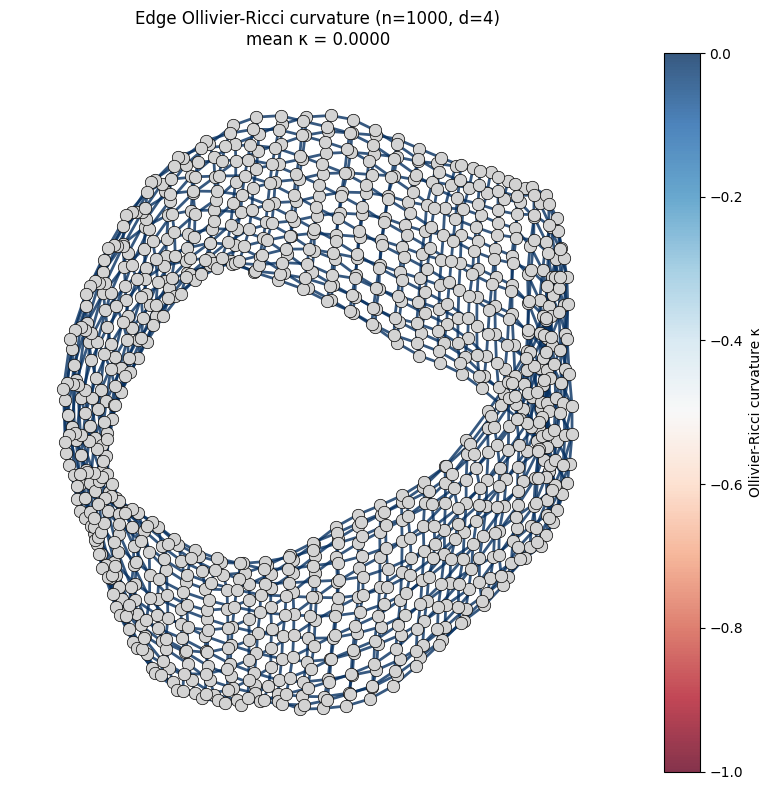

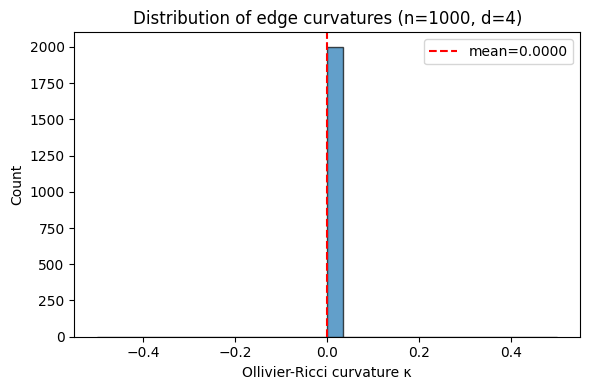

In [43]:
# Cell: #VSC-27ef2dcb
import numpy as np
import networkx as nx
from scipy.optimize import linprog

# --- Ollivier-Ricci curvature ---
def ollivier_ricci_curvature(G, u, v, alpha=0.0):
    """
    Compute Ollivier-Ricci curvature on edge (u,v).
    
    alpha=0  : lazy random walk with uniform measure on neighbors (standard Ollivier).
    alpha>0  : fraction of mass kept at the node itself (idleness).
               mu_u = alpha * delta_u + (1-alpha) * uniform(neighbors(u))
    """
    Nu = list(G.neighbors(u))
    Nv = list(G.neighbors(v))
    
    # Support sets
    supp_u = [u] + Nu
    supp_v = [v] + Nv
    all_nodes = list(set(supp_u + supp_v))
    node_idx = {node: i for i, node in enumerate(all_nodes)}
    m = len(all_nodes)
    
    # Measures mu_u and mu_v
    mu = np.zeros(m)
    mv = np.zeros(m)
    
    mu[node_idx[u]] = alpha
    for nb in Nu:
        mu[node_idx[nb]] += (1 - alpha) / len(Nu)
    
    mv[node_idx[v]] = alpha
    for nb in Nv:
        mv[node_idx[nb]] += (1 - alpha) / len(Nv)
    
    # Distance matrix between support nodes
    D = np.zeros((m, m))
    for i, ni in enumerate(all_nodes):
        for j, nj in enumerate(all_nodes):
            if i <= j:
                d = nx.shortest_path_length(G, ni, nj)
                D[i, j] = d
                D[j, i] = d
    
    # Solve optimal transport (Wasserstein-1) via LP
    # Variables: pi[i,j] for i in supp(mu), j in supp(mv)
    c = D.flatten()  # cost vector
    
    # Constraints: row sums = mu, col sums = mv
    A_eq = []
    b_eq = []
    
    # Row constraints: sum_j pi[i,j] = mu[i]
    for i in range(m):
        row = np.zeros(m * m)
        row[i * m:(i + 1) * m] = 1.0
        A_eq.append(row)
        b_eq.append(mu[i])
    
    # Column constraints: sum_i pi[i,j] = mv[j]
    for j in range(m):
        col = np.zeros(m * m)
        col[j::m] = 1.0
        A_eq.append(col)
        b_eq.append(mv[j])
    
    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)
    bounds = [(0, None)] * (m * m)
    
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    W1 = res.fun  # Wasserstein-1 distance
    
    d_uv = nx.shortest_path_length(G, u, v)
    return 1.0 - W1 / d_uv


# --- Compute curvature for every edge ---

edge_curvatures = {}
for u, v in G.edges():
    kappa = ollivier_ricci_curvature(G, u, v, alpha=0.0)
    edge_curvatures[(u, v)] = kappa

curvature_vals = np.array(list(edge_curvatures.values()))

print(f"Ollivier-Ricci curvature on {len(edge_curvatures)} edges:")
print(f"  mean  = {np.mean(curvature_vals):.4f}")
print(f"  std   = {np.std(curvature_vals):.4f}")
print(f"  min   = {np.min(curvature_vals):.4f}")
print(f"  max   = {np.max(curvature_vals):.4f}")

# --- Visualize: color edges by curvature ---
pos = nx.spring_layout(G, seed=0)

fig, ax = plt.subplots(figsize=(8, 8))

edges = list(edge_curvatures.keys())
colors = [edge_curvatures[e] for e in edges]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=80, node_color="lightgray",
                       edgecolors="black", linewidths=0.5)
ec = nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, edge_color=colors,
                            edge_cmap=plt.cm.RdBu, width=2.0, alpha=0.8,
                            edge_vmin=-1, edge_vmax=0)
plt.colorbar(ec, ax=ax, label="Ollivier-Ricci curvature κ")

ax.set_title(f"Edge Ollivier-Ricci curvature (n={n}, d={d})\n"
             f"mean κ = {np.mean(curvature_vals):.4f}")
ax.axis("off")
plt.tight_layout()
plt.show()

# --- Histogram ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(curvature_vals, bins=30, edgecolor="black", alpha=0.7)
ax.axvline(np.mean(curvature_vals), color="red", linestyle="--", label=f"mean={np.mean(curvature_vals):.4f}")
ax.set_xlabel("Ollivier-Ricci curvature κ")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of edge curvatures (n={n}, d={d})")
ax.legend()
plt.tight_layout()
plt.show()

max |U†U - I| = 3.9968028886505635e-15
done; max |z| = 0.00968167388848338


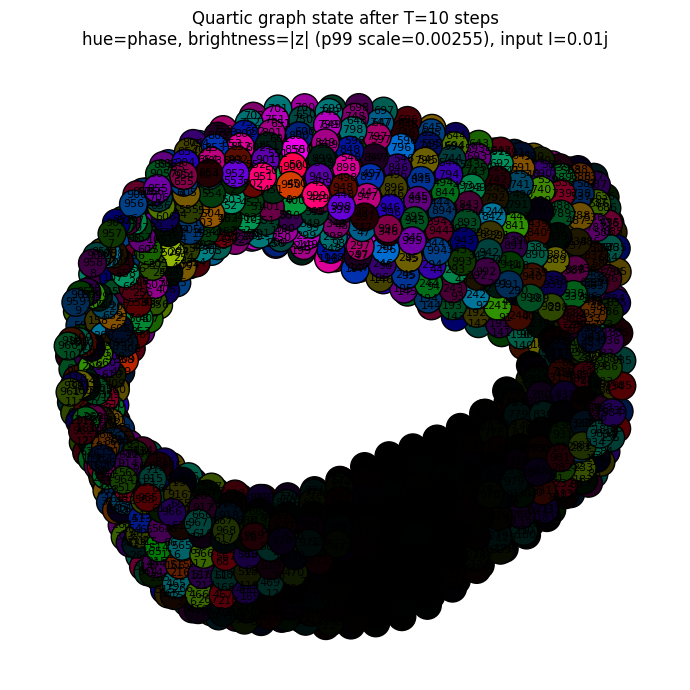

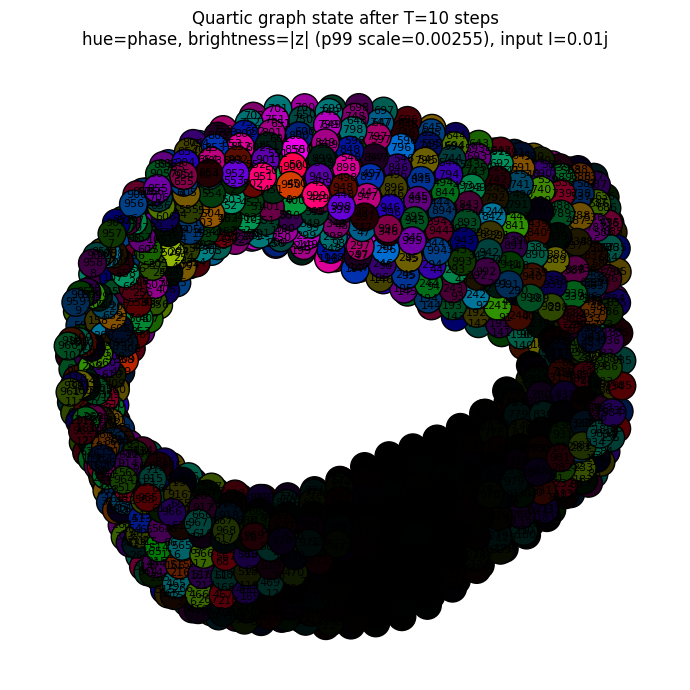

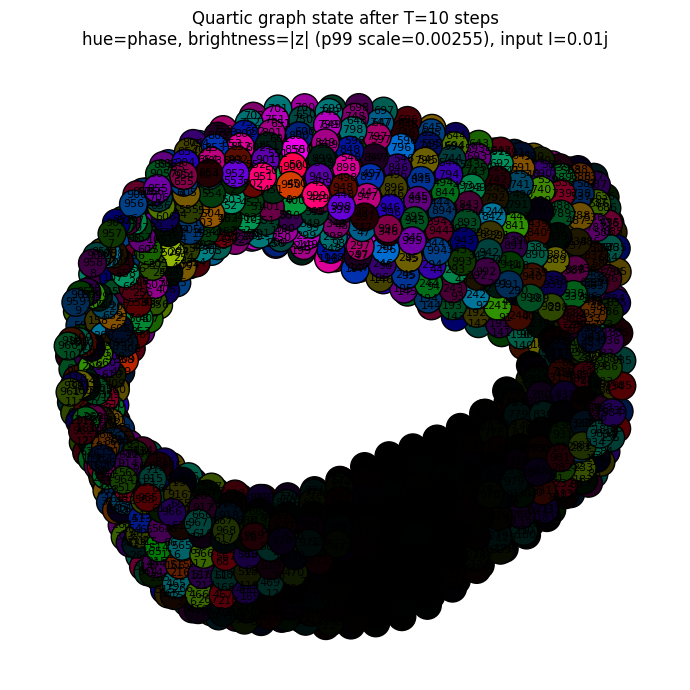

In [48]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm
from matplotlib.colors import hsv_to_rgb
np.random.seed(0)

# Use the graph G built in Cell 5 (torus) / Cell 6 (ORC)
Z = G
n = Z.number_of_nodes()
d = Z.degree(0)           # degree of node 0 (all nodes are 4-regular on the torus)
T = 10
I = 0.0 + 0.01j          # constant complex input added to node 0 each step
dt = 1.0                  # optional scale for the generator i*L

def phi(Z):
    return Z / np.sqrt(1.0 + np.abs(Z)**2)

# Graph Laplacian L (Hermitian/symmetric) and anti-Hermitian generator A = i*L
A_adj = nx.to_numpy_array(Z, nodelist=range(n), dtype=float)
deg = A_adj.sum(axis=1)
L = np.diag(deg) - A_adj                 # combinatorial Laplacian, symmetric real
A = 1j * dt * L                          # anti-Hermitian (since L^T=L => (iL)† = -iL)
# Unitary kernel
U = expm(A)                              # should be unitary (up to numerical error)

# Quick sanity check: U†U ≈ I
unitarity_err = np.max(np.abs(U.conj().T @ U - np.eye(n)))
print("max |U†U - I| =", unitarity_err)

# Recurrent update: z <- phi(U z + I_vec)
z = np.zeros(n, dtype=np.complex128)     # node states
I_vec = np.zeros(n, dtype=np.complex128)
I_vec[0] = I

for t in range(T):
    z_lin = U @ z + I_vec
    z = phi(z_lin)

print("done; max |z| =", np.max(np.abs(z)))

# Visualization: phase as hue, magnitude as brightness
mag = np.abs(z)
scale = np.percentile(mag, 99) if np.any(mag) else 1.0
scale = float(scale) if scale > 0 else 1.0
v = np.clip(mag / scale, 0.0, 1.0)                 # value/brightness
h = (np.angle(z) + np.pi) / (2 * np.pi)            # hue in [0,1]
s = np.ones_like(h)                                 # full saturation
rgb = hsv_to_rgb(np.stack([h, s, v], axis=-1))
pos = nx.spring_layout(Z, seed=0)  # layout for visualization (not part of dynamics)

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(Z, pos, alpha=0.25, width=1.0)
nx.draw_networkx_nodes(
    Z, pos,
    node_color=rgb,
    node_size=400,
    linewidths=1.0,
    edgecolors="black"
)
nx.draw_networkx_labels(Z, pos, font_size=8)

plt.title(f"Quartic graph state after T={T} steps\n"
          f"hue=phase, brightness=|z| (p99 scale={scale:.3g}), input I={I}")
plt.axis("off")
plt.tight_layout()
plt.show()